In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sea
import scipy as sp
%matplotlib inline

In [58]:
pd.set_option('display.max_columns', None)

## Load Dataset

In [59]:
dataset = pd.read_csv("ipl_deliveries.csv")

In [60]:
dataset.head()

,Unnamed: 0,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
2,2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,4,0,4,NaN,NaN,NaN
3,3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN
4,4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,2,0,0,0,0,0,2,2,NaN,NaN,NaN


In [61]:
dataset.isna().sum()
delivery_dataset = dataset.copy()

### Filling Missing values

In [62]:
### Filling in missing values: in player_dismissed, dismissal_kind, fielder.

delivery_dataset['player_dismissed'] = delivery_dataset['player_dismissed'].fillna('not out')

delivery_dataset['dismissal_kind'] = delivery_dataset['dismissal_kind'].fillna('N/A')

delivery_dataset['fielder'] = delivery_dataset['fielder'].fillna('N/A')

### Dropping Duplicates

In [63]:
# display(delivery_dataset.loc[delivery_dataset.duplicated().sum()])
print(f"Number of duplicated rows before: {delivery_dataset.duplicated().sum()}")

print(f"Number of duplicated rows after: {delivery_dataset.duplicated().sum()}")

Number of duplicated rows before: 0
Number of duplicated rows after: 0


In [64]:
delivery_dataset.head()

,Unnamed: 0,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,not out,N/A,N/A
1,1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,not out,N/A,N/A
2,2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,4,0,4,not out,N/A,N/A
3,3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0,not out,N/A,N/A
4,4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,2,0,0,0,0,0,2,2,not out,N/A,N/A


### Standardising Team Names

In [65]:
all_teams = np.unique(delivery_dataset['batting_team'])

print(f"Teams before standardising names: {len(all_teams)}")
display(all_teams)

same_team_names = {
    'Rising Pune Supergiants' : 'Rising Pune Supergiant',
    'Delhi Daredevils' : 'Delhi Capitals',
    'Deccan Chargers' : 'Sunrisers Hyderabad',
    'Kings XI Punjab' : 'Punjab Kings'
}

## Function to standardised team name:
def standardised_team_names(df,columns):
    for col in columns:
        df[col] = df[col].replace(same_team_names)
    return df

team_columns = ['batting_team', 'bowling_team']
delivery_dataset = standardised_team_names(delivery_dataset, team_columns)

all_teams = np.unique(delivery_dataset['batting_team'])
print(f"Teams after standardising names: {len(all_teams)}")
display(all_teams)

Teams before standardising names: 14


array(['Chennai Super Kings', 'Deccan Chargers', 'Delhi Daredevils',
       'Gujarat Lions', 'Kings XI Punjab', 'Kochi Tuskers Kerala',
       'Kolkata Knight Riders', 'Mumbai Indians', 'Pune Warriors',
       'Rajasthan Royals', 'Rising Pune Supergiant',
       'Rising Pune Supergiants', 'Royal Challengers Bangalore',
       'Sunrisers Hyderabad'], dtype=object)

Teams after standardising names: 12


array(['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Lions',
       'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Mumbai Indians',
       'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals',
       'Rising Pune Supergiant', 'Royal Challengers Bangalore',
       'Sunrisers Hyderabad'], dtype=object)

### Finding the batsman stats first:

Top socring batsman, most dismissed batsman, batsman total balls, 
strike rate, total_dismissals, batting average, batsman fours and sixes,
boundary %tage, runs per match, count hundreds, count fifties, strike rate. 

In [66]:
batsman_team = delivery_dataset.groupby('batsman')['batting_team'].unique()

In [67]:
# Finding the batsman stats first:
# batsman total balls balls
batsman_total_balls = delivery_dataset['batsman'].value_counts().reset_index()
batsman_total_balls.rename(columns={'count':'no.of_balls'}, inplace=True)


# batsman runs
batsman_runs = delivery_dataset.groupby('batsman')['batsman_runs'].sum().sort_values(ascending=False).reset_index()


#making a new df for batsman and will use this for eda!
batsman_stats = pd.merge(batsman_runs, batsman_total_balls, on='batsman', how='left')


# batsman dismissals
batsman_dismissals = delivery_dataset['player_dismissed'].value_counts().reset_index()
batsman_dismissals.columns = ['batsman', 'dismissals_count']
batsman_dismissals = batsman_dismissals[batsman_dismissals['batsman'] != 'not out']
# merging:
batsman_stats = pd.merge(batsman_stats, batsman_dismissals, on='batsman', how='left')
batsman_stats['dismissals_count'] = batsman_stats['dismissals_count'].fillna(0)

#total matches played.
total_matches_played_by_batsman = delivery_dataset.groupby('batsman')['match_id'].nunique().reset_index()
batsman_stats = pd.merge(batsman_stats, total_matches_played_by_batsman,on='batsman', how='left')
batsman_stats.rename(columns={'match_id':'matches_played'},inplace=True)


#strike rate
batsman_stats['strike_rate'] = (batsman_stats['batsman_runs'] / batsman_stats['no.of_balls'].replace(0,np.nan)) * 100
batsman_stats['strike_rate'] = batsman_stats['strike_rate'].fillna(np.inf)


# batting average
batsman_stats['batting_average'] = batsman_stats['batsman_runs'] / batsman_stats['dismissals_count'].replace(0,np.nan)
batsman_stats['batting_average'] = batsman_stats['batting_average'].fillna(np.inf)


# batsman and played teams
batsman_stats = pd.merge(batsman_stats, batsman_team, on='batsman', how='left')


# bstsman fours and sixes.
batsman_fours = delivery_dataset[delivery_dataset['batsman_runs'] == 4].groupby('batsman')['batsman_runs'].count().reset_index()
batsman_fours.rename(columns={'batsman_runs':'no_of_fours'}, inplace=True)

batsman_sixes= delivery_dataset[delivery_dataset['batsman_runs'] == 6].groupby('batsman')['batsman_runs'].count().reset_index()
batsman_sixes.rename(columns={'batsman_runs':'no_of_sixes'}, inplace=True)

batsman_stats = pd.merge(batsman_stats, batsman_fours, on='batsman', how='left')
batsman_stats = pd.merge(batsman_stats, batsman_sixes, on='batsman', how='left')

batsman_stats['no_of_fours'] = batsman_stats['no_of_fours'].fillna(0).astype(int)
batsman_stats['no_of_sixes'] = batsman_stats['no_of_sixes'].fillna(0).astype(int)


# boundary percentage
batsman_stats['boundary_percentage'] = (
    ((batsman_stats['no_of_fours'] * 4) + (batsman_stats['no_of_sixes'] * 6)) / batsman_stats['batsman_runs'].replace(0,np.nan)) * 100

batsman_stats['boundary_percentage'] = batsman_stats['boundary_percentage'].fillna(0)


##batsman_runs_per_match
batsman_runs_per_match = delivery_dataset.groupby(['match_id','batsman'])['batsman_runs'].sum().reset_index()

def count_hundreds(runs):
    return (runs>=100).sum()

def count_fifties(runs):
    return (runs>=50).sum()

hundreds = batsman_runs_per_match.groupby('batsman')['batsman_runs'].apply(count_hundreds).reset_index(name='no_of_100s')
fifties = batsman_runs_per_match.groupby('batsman')['batsman_runs'].apply(count_fifties).reset_index(name='no_of_50s')

batsman_stats = pd.merge(batsman_stats, hundreds, on='batsman', how='left')
batsman_stats = pd.merge(batsman_stats, fifties, on='batsman', how='left')

batsman_stats['no_of_100s']= batsman_stats['no_of_100s'].fillna(0).astype(int)
batsman_stats['no_of_50s']= batsman_stats['no_of_50s'].fillna(0).astype(int)

In [68]:
batsman_stats

,batsman,batsman_runs,no.of_balls,dismissals_count,matches_played,strike_rate,batting_average,batting_team,no_of_fours,no_of_sixes,boundary_percentage,no_of_100s,no_of_50s
0,SK Raina,4548,3369,134.0,157,134.995548,33.940299,"[Gujarat Lions, Chennai Super Kings]",402,174,58.311346,1,32
1,V Kohli,4423,3494,118.0,141,126.588437,37.483051,[Royal Challengers Bangalore],384,160,56.432286,4,35
2,RG Sharma,4207,3274,129.0,153,128.497251,32.612403,"[Mumbai Indians, Sunrisers Hyderabad]",354,173,58.331353,1,33
3,G Gambhir,4132,3433,131.0,146,120.361200,31.541985,"[Kolkata Knight Riders, Delhi Capitals]",484,58,55.275895,0,35
4,DA Warner,4014,2902,100.0,114,138.318401,40.140000,"[Sunrisers Hyderabad, Delhi Capitals]",401,160,63.876432,3,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...
456,Abdur Razzak,0,2,0.0,1,0.000000,inf,[Royal Challengers Bangalore],0,0,0.000000,0,0
457,S Kaushik,0,1,1.0,1,0.000000,0.000000,[Gujarat Lions],0,0,0.000000,0,0
458,S Ladda,0,10,1.0,2,0.000000,0.000000,[Delhi Capitals],0,0,0.000000,0,0
459,U Kaul,0,1,0.0,1,0.000000,inf,[Punjab Kings],0,0,0.000000,0,0


### Bowler Stats

Finding the bowler stats:
bowler who bowled most balls, most run giving bowler(conceeded), most_wide, most_no balls, bye runs, legbye runs, penalty runs, extra runs overall.
 bowler credited dismisalls, wicket by bowlers, bpowling avg, matches_played by bowler,no.of balls bowled, total_overs, dot balls, wickets pers match, 4 wicket haul and 5 wicket haul, 
bowling_economy, avg dot balls, bowling_SR, 


In [69]:
#balls bowled by bowler
total_balls_bowled = delivery_dataset['bowler'].value_counts().reset_index()
total_balls_bowled.rename(columns={'count':'balls bowled'},inplace=True)
#total runs conceeded
total_runs_conceeded_by_bowler = delivery_dataset.groupby('bowler')['total_runs'].sum().sort_values(ascending=False).reset_index()
total_runs_conceeded_by_bowler.rename(columns={'total_runs':'runs_conceded'}, inplace=True)

#bowler stats
bowler_stats = pd.merge(total_runs_conceeded_by_bowler,total_balls_bowled,on='bowler', how='left')



# most wides
bowled_most_wide = delivery_dataset.groupby('bowler')['wide_runs'].sum().sort_values(ascending= False).reset_index()
bowled_most_wide.rename(columns={'count':'wide balls'}, inplace=True)
bowler_stats = (pd.merge(bowler_stats, bowled_most_wide, on='bowler', how='left'))

# most no balls
bowled_most_no_balls = delivery_dataset.groupby('bowler')['noball_runs'].sum().sort_values(ascending= False).reset_index()
bowled_most_wide.rename(columns={'count':'no balls'}, inplace=True)
bowler_stats = (pd.merge(bowler_stats, bowled_most_no_balls, on='bowler', how='left'))

#most bye runs
bowled_most_by_runs = delivery_dataset.groupby('bowler')['bye_runs'].sum().sort_values(ascending= False).reset_index()
bowled_most_wide.rename(columns={'count':'bye runs'}, inplace=True)
bowler_stats = (pd.merge(bowler_stats,bowled_most_by_runs , on='bowler', how='left'))

# most leg bye
bowled_most_leg_bye = delivery_dataset.groupby('bowler')['legbye_runs'].sum().sort_values(ascending= False).reset_index()
bowled_most_wide.rename(columns={'count':'leg bye runs'}, inplace=True)
bowler_stats = (pd.merge(bowler_stats, bowled_most_leg_bye , on='bowler', how='left'))

# most penalty runs
bowled_most_penalty_runs = delivery_dataset.groupby('bowler')['penalty_runs'].sum().sort_values(ascending=False).reset_index()
bowled_most_wide.rename(columns={'count':'penalty runs'}, inplace=True)
bowler_stats = (pd.merge(bowler_stats, bowled_most_penalty_runs , on='bowler', how='left'))

# msot extra runs overall
bowled_extra_runs = delivery_dataset.groupby('bowler')['extra_runs'].sum().sort_values(ascending=False).reset_index()
bowled_most_wide.rename(columns={'count':'extra runs'}, inplace=True)
bowler_stats = (pd.merge(bowler_stats,bowled_extra_runs , on='bowler', how='left'))

#bowler credited wickets
bowler_credited_dismissal = delivery_dataset[
    delivery_dataset['dismissal_kind'].isin(['caught', 'bowled', 'lbw' ,'stumped', 'caught and bowled'])
]

wickets_by_bowler = bowler_credited_dismissal.groupby('bowler')['dismissal_kind'].count().sort_values(ascending=False)
wickets_by_bowler = wickets_by_bowler.reset_index()
wickets_by_bowler.rename(columns= {'dismissal_kind':'no_of_wickets'}, inplace=True)
bowler_stats = (pd.merge(bowler_stats, wickets_by_bowler, on='bowler', how='left'))
bowler_stats['no_of_wickets'] = bowler_stats['no_of_wickets'].fillna(0).astype(int)

# Bowler stats: bowling_avg, totalmatches, total overs, total dot balls, wicket per match (matchid), four wickets, five wickets, 
# bowling economy, avg  dot balls, bowling SR 
bowler_stats['bowling_average'] = bowler_stats['runs_conceded'] / bowler_stats['no_of_wickets'].replace(0,np.nan)
bowler_stats['bowling_average'] = bowler_stats['bowling_average'].fillna(0)

#total matches played.
total_matches_played_by_bowler = delivery_dataset.groupby('bowler')['match_id'].nunique()
bowler_stats = pd.merge(bowler_stats, total_matches_played_by_bowler,on='bowler', how='left')
bowler_stats.rename(columns={'match_id':'matches_played'},inplace=True)

#total overs
total_overs = delivery_dataset.groupby('bowler')['over'].nunique().reset_index()
total_overs.rename(columns={'over':'no_of_overs'}, inplace=True)
bowler_stats = pd.merge(bowler_stats, total_overs, on='bowler', how='left')

# #total dot balls
total_dot_balls= delivery_dataset[delivery_dataset['total_runs'] == 0].groupby('bowler')['total_runs'].value_counts().reset_index()
total_dot_balls.rename(columns={'count':'dot balls'},inplace=True)
bowler_stats = pd.merge(bowler_stats, total_dot_balls, on='bowler',how='left')
bowler_stats.drop(columns=['total_runs'],axis=1)
bowler_stats['dot balls'] = bowler_stats['dot balls'].fillna(0).astype(int)

# #bowler wickets per match  
bowler_wickets_per_match = bowler_credited_dismissal.groupby(['match_id','bowler'])['dismissal_kind'].count().reset_index()
bowler_wickets_per_match.rename(columns={'dismissal_kind':'wickets_in_match'},inplace=True)


# #4 and 5 wickets haul
four_wicks_haul = bowler_wickets_per_match[bowler_wickets_per_match['wickets_in_match'] >= 4].groupby('bowler')['match_id'].count().reset_index(name='four_plus_wickets')
five_wicks_haul = bowler_wickets_per_match[bowler_wickets_per_match['wickets_in_match'] >= 5].groupby('bowler')['match_id'].count().reset_index(name='five_plus_wickets')
bowler_stats = pd.merge(bowler_stats,four_wicks_haul,on='bowler', how='left')
bowler_stats = pd.merge(bowler_stats,five_wicks_haul,on='bowler', how='left')

bowler_stats['four_plus_wickets'] = bowler_stats['four_plus_wickets'].fillna(0).astype(int)
bowler_stats['five_plus_wickets'] = bowler_stats['five_plus_wickets'].fillna(0).astype(int)


# bowline_economy
bowler_stats['bowling_economy'] = bowler_stats['runs_conceded'] / bowler_stats['no_of_overs'].replace(0,np.nan)
bowler_stats['bowling_economy'] = bowler_stats['bowling_economy'].fillna(np.inf)

#avg dot balls
bowler_stats['average_dot_balls'] = ((bowler_stats['dot balls']/bowler_stats['balls bowled']) * 100).replace(0,np.nan)
bowler_stats['average_dot_balls'] = bowler_stats['average_dot_balls'].fillna(np.inf)

#bowling strike rate
bowler_stats['bowling_strike_rate'] = bowler_stats['balls bowled'] / bowler_stats['no_of_wickets'].replace(0, np.nan)
bowler_stats['bowling_strike_rate'] = bowler_stats['bowling_strike_rate'].fillna(np.inf)

bowler_stats = bowler_stats.drop(columns=['total_runs'], axis=1)

In [70]:
bowler_stats.head(20)

display(bowler_stats.isna().sum())

bowler                 0
runs_conceded          0
balls bowled           0
wide_runs              0
noball_runs            0
bye_runs               0
legbye_runs            0
penalty_runs           0
extra_runs             0
no_of_wickets          0
bowling_average        0
matches_played         0
no_of_overs            0
dot balls              0
four_plus_wickets      0
five_plus_wickets      0
bowling_economy        0
average_dot_balls      0
bowling_strike_rate    0
dtype: int64

In [71]:
dismissal_kinds_frequency = delivery_dataset['dismissal_kind'].value_counts().sort_values(ascending=False)
dismissal_kinds_frequency == dismissal_kinds_frequency[dismissal_kinds_frequency != 'N/A']


## Fielder caught most
fielder_who_caught_most_balls = delivery_dataset['fielder'].value_counts().reset_index()
fielder_who_caught_most_balls = fielder_who_caught_most_balls[fielder_who_caught_most_balls['fielder'] !='N/A']

display(fielder_who_caught_most_balls)

## Teams and extra runs
teams_extra_runs = delivery_dataset.groupby('bowling_team')['extra_runs'].sum().sort_values()

## Matchup Countsabs
all_matchups = delivery_dataset[['batting_team','bowling_team']].value_counts().reset_index()
all_matchups['Matchups'] = all_matchups['batting_team'].astype(str) + ' ' + 'v/s '  + all_matchups['bowling_team'].astype(str)
all_matchups.drop(columns=['batting_team','bowling_team'],inplace=True)
display(all_matchups)

,fielder,count
1,KD Karthik,127
2,MS Dhoni,126
3,RV Uthappa,115
4,AB de Villiers,101
5,SK Raina,96
...,...,...
447,Sunny Singh,1
448,R Ninan,1
449,MD Mishra,1
450,AA Bilakhia,1


,count,Matchups
0,2685,Chennai Super Kings v/s Mumbai Indians
1,2662,Mumbai Indians v/s Chennai Super Kings
2,2590,Punjab Kings v/s Kolkata Knight Riders
3,2574,Royal Challengers Bangalore v/s Mumbai Indians
4,2556,Mumbai Indians v/s Royal Challengers Bangalore
...,...,...
111,123,Kochi Tuskers Kerala v/s Pune Warriors
112,123,Pune Warriors v/s Kochi Tuskers Kerala
113,121,Kochi Tuskers Kerala v/s Mumbai Indians
114,118,Punjab Kings v/s Kochi Tuskers Kerala


In [72]:
# bowler_stats.to_csv('bowler_stats.csv')
batsman_stats.to_csv('batsman_stats.csv')

## Bowler Performance Analysis

Analysing the `bowler_stats.csv` in detail.

In [73]:
df = pd.read_csv('bowler_stats.csv')

display(df.shape)
display(df.info())


(356, 20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 356 entries, 0 to 355
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           356 non-null    int64  
 1   bowler               356 non-null    object 
 2   runs_conceded        356 non-null    int64  
 3   balls bowled         356 non-null    int64  
 4   wide_runs            356 non-null    int64  
 5   noball_runs          356 non-null    int64  
 6   bye_runs             356 non-null    int64  
 7   legbye_runs          356 non-null    int64  
 8   penalty_runs         356 non-null    int64  
 9   extra_runs           356 non-null    int64  
 10  no_of_wickets        356 non-null    int64  
 11  bowling_average      356 non-null    float64
 12  matches_played       356 non-null    int64  
 13  no_of_overs          356 non-null    int64  
 14  dot balls            356 non-null    int64  
 15  four_plus_wickets    356 non-null    int

None

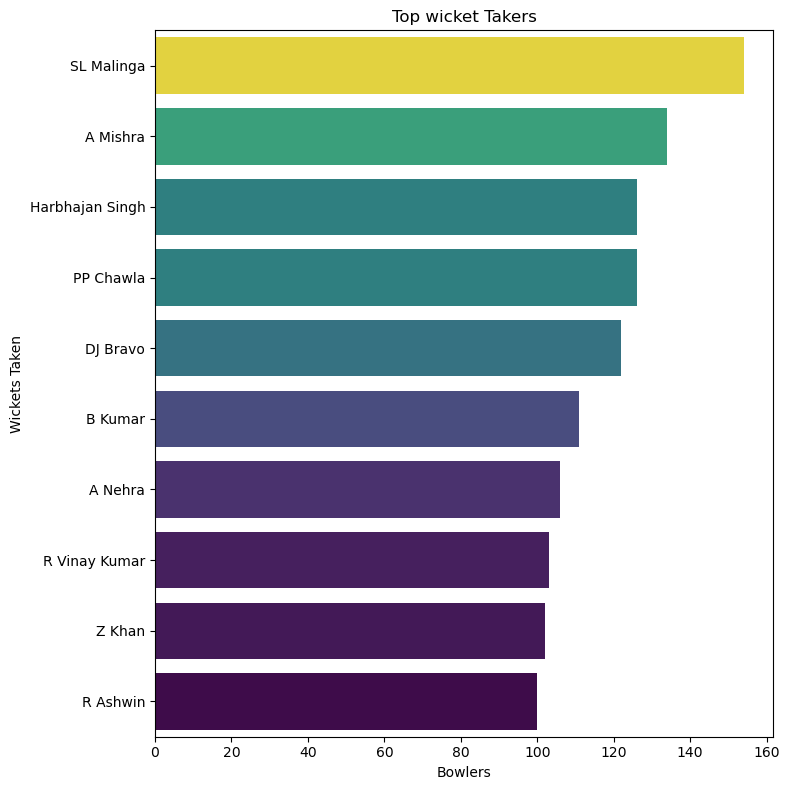

In [74]:
## 1. Who are top wicket takers in IPL.

top_wicket_taking_bowlers = df.sort_values(by='no_of_wickets', ascending=False)
# display(top_10_bowlers)

plt.figure(figsize=(8,8))
sea.barplot(x = 'no_of_wickets',y='bowler', data=top_wicket_taking_bowlers.head(10), hue='no_of_wickets', palette='viridis', legend=False)
plt.xlabel("Bowlers")
plt.ylabel("Wickets Taken")
plt.title("Top wicket Takers")
plt.tight_layout()
plt.show()

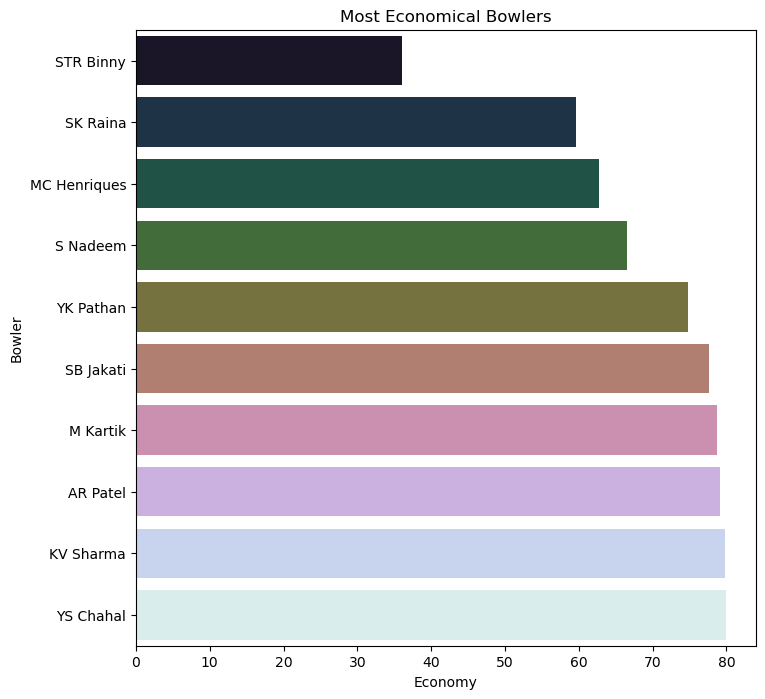

In [75]:
## 2. Who are the most economical bowlers?

top_economical_bowlers = df.sort_values(by='bowling_economy', ascending=True)
top_economical_bowlers = top_economical_bowlers[top_economical_bowlers['matches_played'] >50]
plt.figure(figsize=(8,8))
sea.barplot(x='bowling_economy', y='bowler', hue='bowler', data= top_economical_bowlers.head(10), palette='cubehelix',legend=False)    
plt.xlabel("Economy")
plt.ylabel("Bowler")
plt.title("Most Economical Bowlers")
plt.show()

            

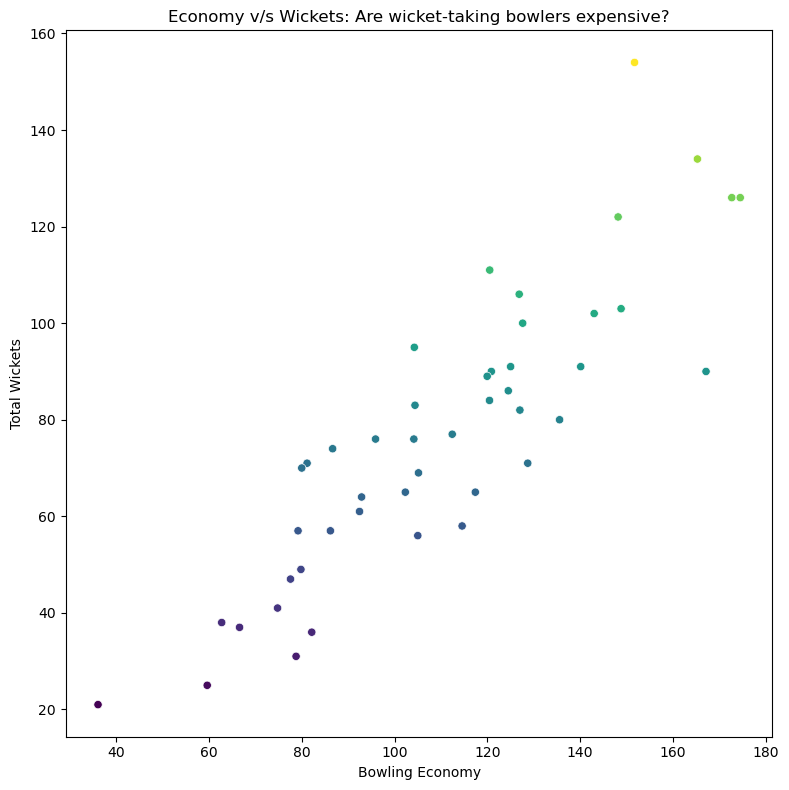

In [76]:
 # Q3. Are the wicket taking bowlers expensive?
data_for_plot = df[df['matches_played'] >= 50]
plt.figure(figsize=(8,8))
sea.scatterplot(data= data_for_plot, x='bowling_economy', y='no_of_wickets', hue='no_of_wickets',palette='viridis', legend=False)
plt.title("Economy v/s Wickets: Are wicket-taking bowlers expensive?")
plt.xlabel("Bowling Economy")
plt.ylabel("Total Wickets")
plt.tight_layout()
plt.show()



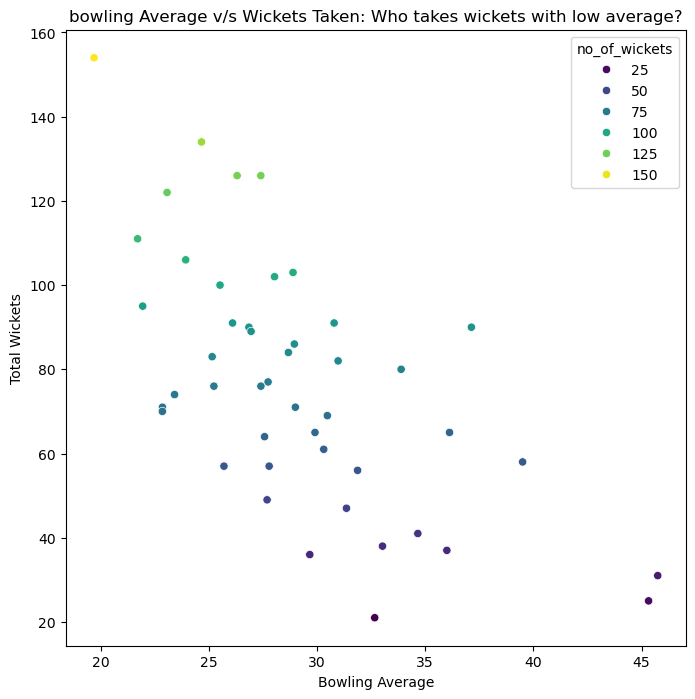

In [77]:
# Q4. Who are the most consistent bowlers.
data_for_plot = df[df['matches_played'] >= 50]
plt.figure(figsize=(8,8))
sea.scatterplot(data=data_for_plot, x='bowling_average', y='no_of_wickets', hue='no_of_wickets', palette='viridis', legend=True)
plt.xlabel("Bowling Average")
plt.ylabel("Total Wickets")
plt.title("bowling Average v/s Wickets Taken: Who takes wickets with low average?")
plt.show()

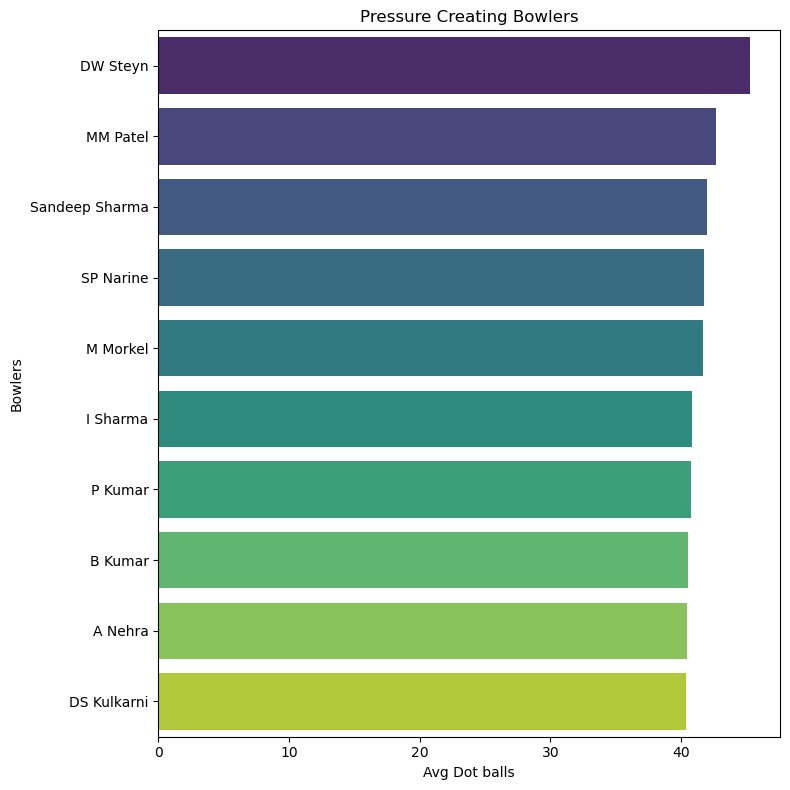

In [78]:
# Q5. Who creates most pressure?
data_for_plot = df[df['matches_played'] >= 50].sort_values(by='average_dot_balls', ascending=False)
plt.figure(figsize=(8,8))
sea.barplot(data=data_for_plot.head(10), x='average_dot_balls', y='bowler', hue='bowler', legend=False, palette='viridis')
plt.title("Pressure Creating Bowlers")
plt.xlabel("Avg Dot balls")
plt.ylabel("Bowlers")
plt.tight_layout()
plt.show()



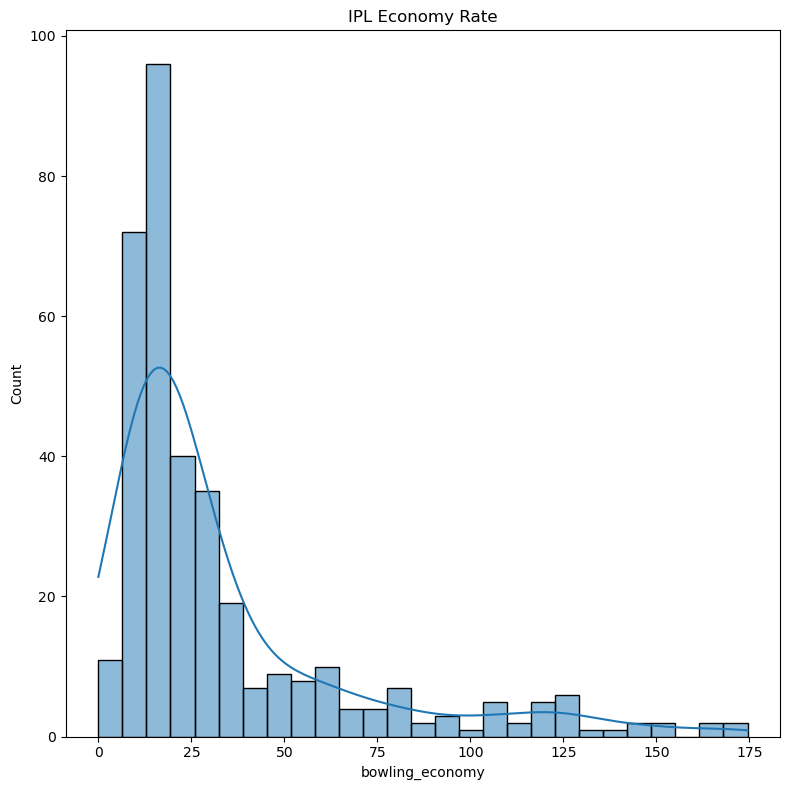

In [79]:
# Q6. Distribution of bowling economy

plt.figure(figsize=(8,8))
sea.histplot(data=df, x='bowling_economy', kde=True)
plt.title("IPL Economy Rate")
plt.xlabel("bowling_economy")
plt.tight_layout()
plt.show()

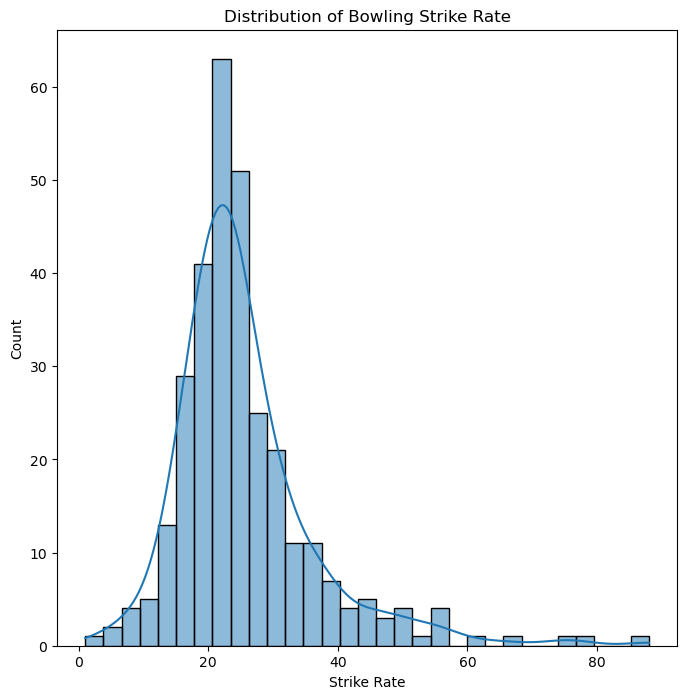

In [80]:
# Q7. Distribution of bowling Strike rate
plt.figure(figsize=(8,8))
sea.histplot(data=df, x='bowling_strike_rate',kde=True)
plt.title("Distribution of Bowling Strike Rate")
plt.xlabel("Strike Rate")
plt.show()

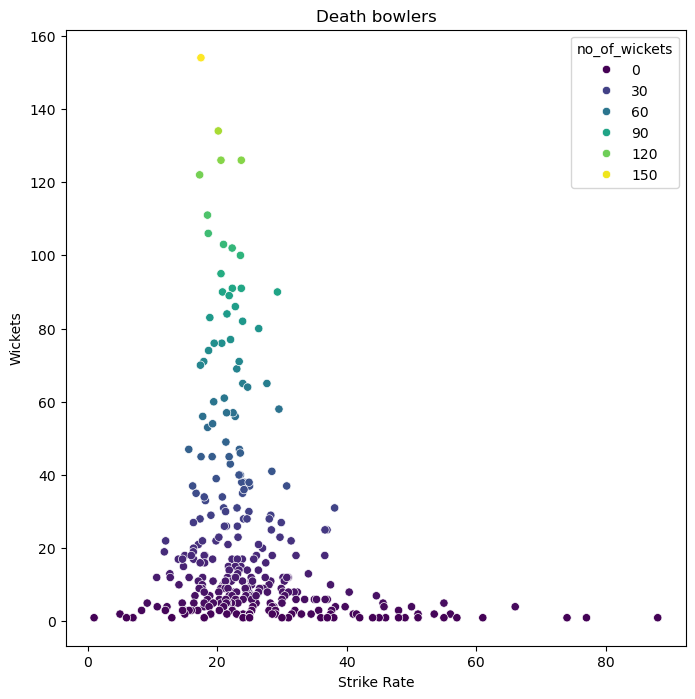

In [81]:
# Q8. Who are the best death/strike bowlers

plt.figure(figsize=(8,8))
sea.scatterplot(data=df, x='bowling_strike_rate', y='no_of_wickets', hue='no_of_wickets', palette='viridis')
plt.title("Death bowlers")
plt.xlabel("Strike Rate")
plt.ylabel("Wickets")
plt.show()

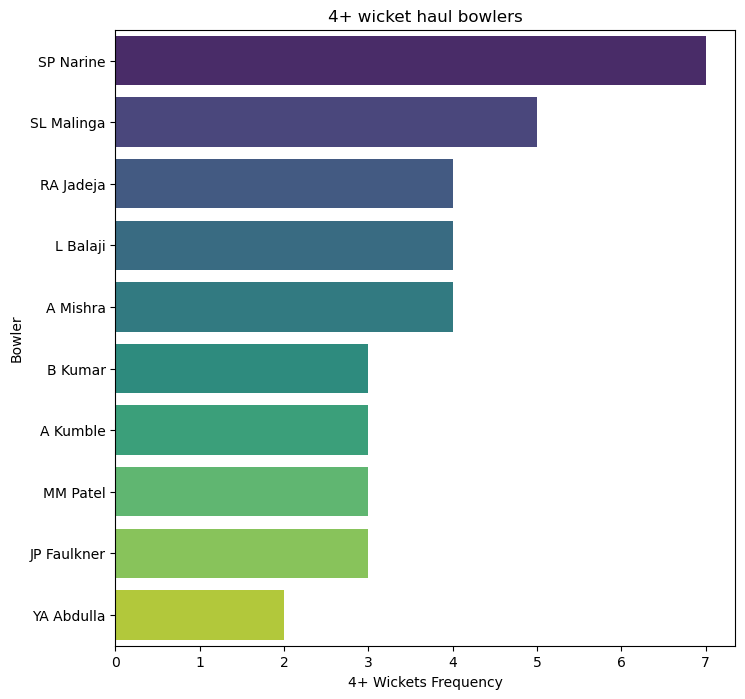

In [82]:
# Q9. Which bowlers take the most 4+ wickets haulabs
plt.figure(figsize=(8,8))
sea.barplot(data=df.sort_values(by='four_plus_wickets', ascending=False).head(10), x='four_plus_wickets',y='bowler',hue='bowler', palette='viridis')
plt.title("4+ wicket haul bowlers")
plt.xlabel("4+ Wickets Frequency")
plt.ylabel("Bowler")
plt.show()

In [83]:
# df.columns

# bowler_score = top_wicket_taking_bowlers[top_wicket_taking_bowlers['matches_played'] >=50]
# bowler_score = bowler_score.sort_values(by='bowling_strike_rate')
# bowler_score = bowler_score.sort_values(by='bowling_economy')
# bowler_score = bowler_score.sort_values(by='average_dot_balls',ascending=False)
# bowler_score = bowler_score.sort_values(by='no_of_wickets', ascending=False)

# bowler_score

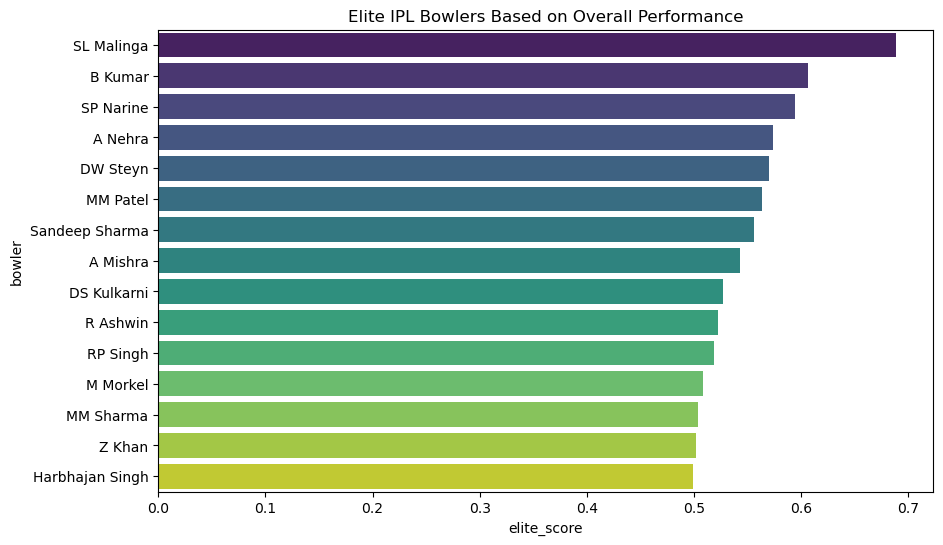

In [84]:
elite_bowlers = df.copy()

elite_bowlers = elite_bowlers[elite_bowlers['matches_played'] >= 50]

## Normalising:abs

elite_bowlers['wicket_score'] = (elite_bowlers['no_of_wickets'] - 
                                 elite_bowlers['no_of_wickets'].min()
                                )/(
                                    elite_bowlers['no_of_wickets'].max() - 
                                    elite_bowlers['no_of_wickets'].min())

elite_bowlers['dot_score'] = (
    elite_bowlers['average_dot_balls'] -
    elite_bowlers['average_dot_balls'].min()
) / (
    elite_bowlers['average_dot_balls'].max() -
    elite_bowlers['average_dot_balls'].min()
)

elite_bowlers['economy_score'] = (
    elite_bowlers['bowling_economy'].max() -
    elite_bowlers['bowling_economy']
) / (
    elite_bowlers['bowling_economy'].max() -
    elite_bowlers['bowling_economy'].min()
)



elite_bowlers['elite_score'] = (
    elite_bowlers['wicket_score'] * 0.5 +
    elite_bowlers['economy_score'] * 0.3 +
    elite_bowlers['dot_score'] * 0.2
)

elite_bowlers = elite_bowlers.sort_values(
    by='elite_score',
    ascending=False
)

elite_bowlers[['bowler','elite_score']].head(15)

plt.figure(figsize=(10,6))

sea.barplot(
    data=elite_bowlers.head(15),
    x='elite_score',
    y='bowler',
    hue='bowler',
    palette='viridis',
)

plt.title("Elite IPL Bowlers Based on Overall Performance")
plt.show()


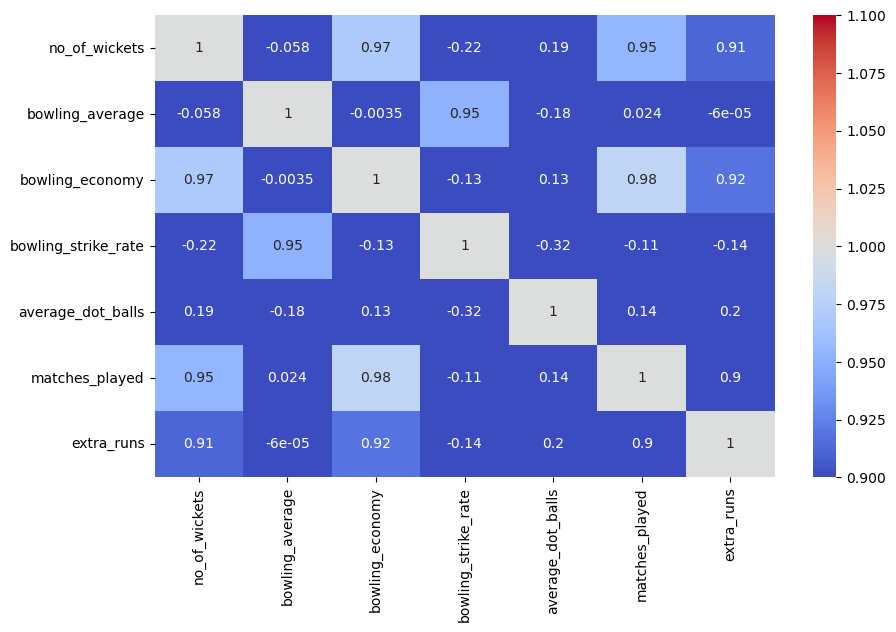

In [85]:
# Q11. Correlation Heatmap. 
selected_columns = df[['no_of_wickets', 'bowling_average', 'bowling_economy', 'bowling_strike_rate', 'average_dot_balls', 'matches_played','extra_runs']]
selected_corr = selected_columns.corr()

plt.figure(figsize=(10,6))
sea.heatmap(selected_corr, annot=True, cmap='coolwarm', vmin=1, vmax=1)
plt.show()

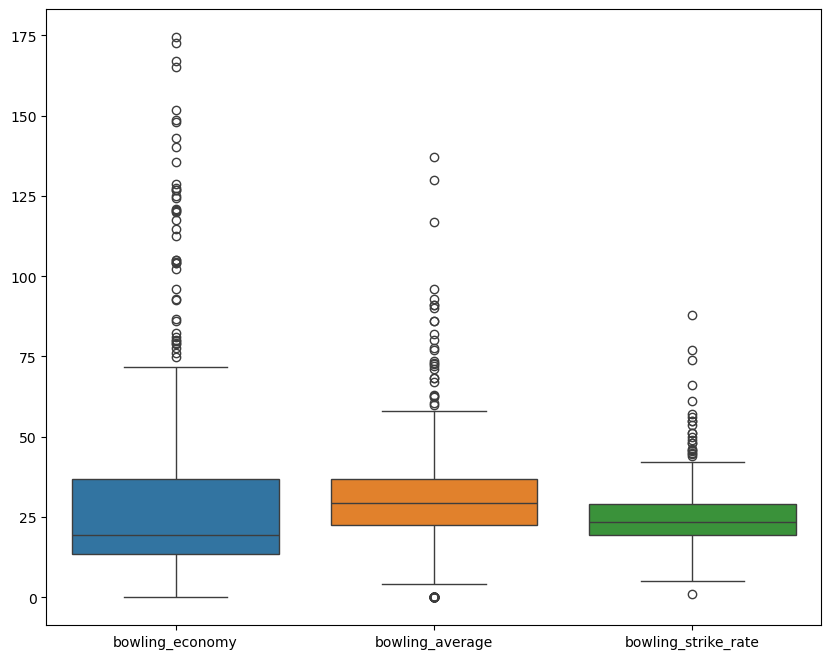

In [86]:
# Q12. Boxplot for outlier detection:
selected_columns = df[['bowling_economy', 'bowling_average', 'bowling_strike_rate']]

plt.figure(figsize=(10,8))
sea.boxplot(selected_columns)
plt.show()

In [87]:
# Q13. Let us check if my cleaned data has any missing values or dupicates.

# display(df.duplicated().sum())
# display(df.isna())
if df.isna().sum().sum() == 0 and df.duplicated().sum() == 0:
    print("## Data quality check: \n")
    print("Missing Values = None\nDuplicates Records = None\nData types verified")
else:
    print("Oh no duplicates/missing values found please remove them")


## Data quality check: 

Missing Values = None
Duplicates Records = None
Data types verified


In [88]:
df.columns

Index(['Unnamed: 0', 'bowler', 'runs_conceded', 'balls bowled', 'wide_runs',
       'noball_runs', 'bye_runs', 'legbye_runs', 'penalty_runs', 'extra_runs',
       'no_of_wickets', 'bowling_average', 'matches_played', 'no_of_overs',
       'dot balls', 'four_plus_wickets', 'five_plus_wickets',
       'bowling_economy', 'average_dot_balls', 'bowling_strike_rate'],
      dtype='object')

## Key Insigths

## Limitations

## Batsman Performance Analysis

Analysing `batsman_stats.csv` in detail and fetching important insights from the data.

In [89]:
df = pd.read_csv('batsman_stats.csv')

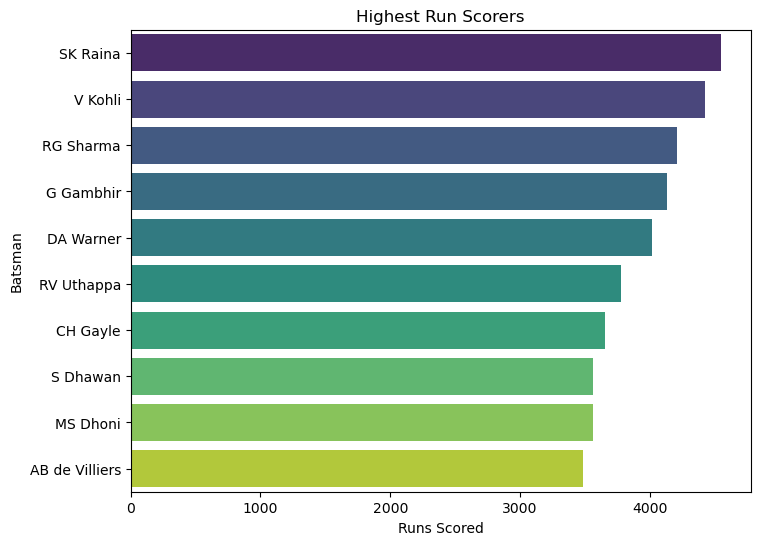

In [90]:
# Q1. who are the highest run scorers
df_plot = df.sort_values(by='batsman_runs', ascending=False)

plt.figure(figsize=(8,6))
sea.barplot(data=df_plot.head(10), x='batsman_runs', y='batsman', hue='batsman', legend=False, palette='viridis')
plt.xlabel("Runs Scored")
plt.ylabel("Batsman")
plt.title("Highest Run Scorers")
plt.show()

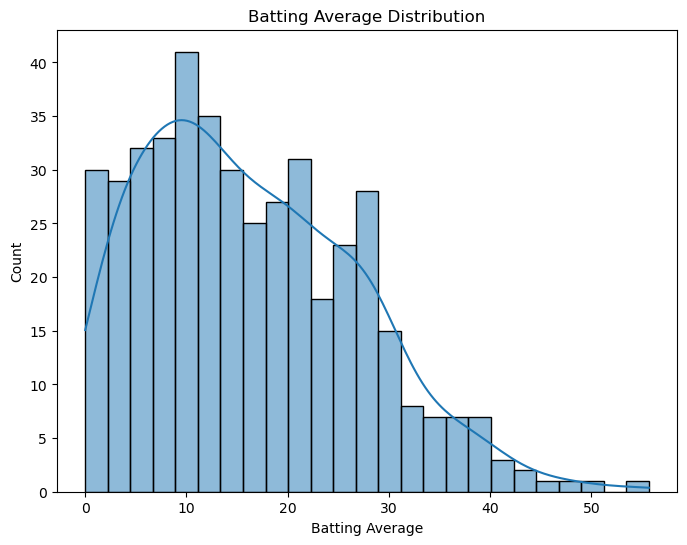

In [91]:
# Q2. How are batting averages distributed

plt.figure(figsize=(8,6))
sea.histplot(data=df,x='batting_average', bins=25, kde=True)
plt.title("Batting Average Distribution")
plt.xlabel("Batting Average")
plt.show()

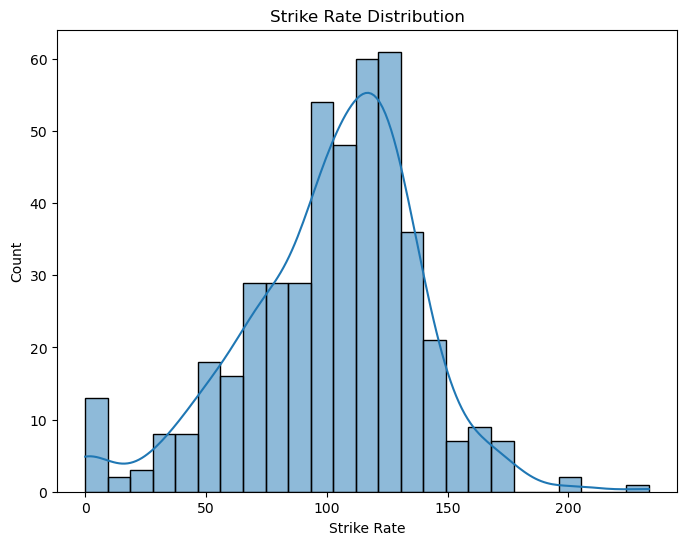

In [92]:
# Q3. How are the strike rates distributed?
plt.figure(figsize=(8,6))
sea.histplot(data=df, x='strike_rate', bins=25, kde=True)
plt.title("Strike Rate Distribution")
plt.xlabel("Strike Rate")
plt.show()

In [93]:
df['batting_average']

0      33.940299
1      37.483051
2      32.612403
3      31.541985
4      40.140000
         ...    
456          inf
457     0.000000
458     0.000000
459          inf
460     0.000000
Name: batting_average, Length: 461, dtype: float64

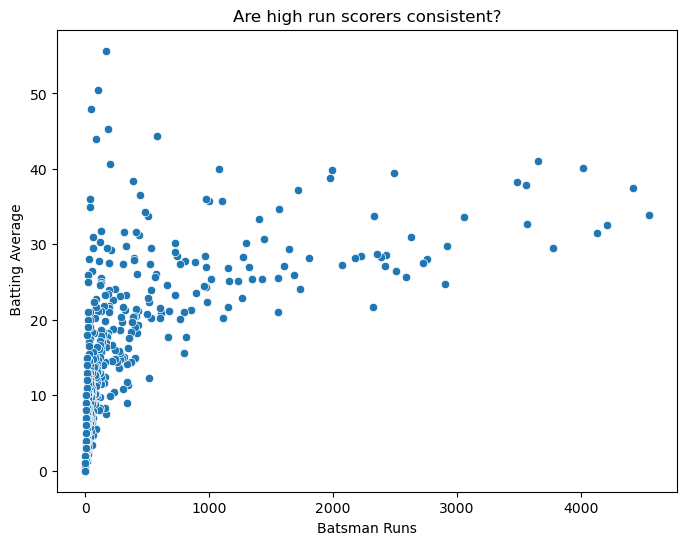

In [94]:
# Q4. Do high run scorers are also consistent?
plt.figure(figsize=(8,6))
sea.scatterplot(data=df, x='batsman_runs', y='batting_average', legend=True)
plt.title("Are high run scorers consistent?")
plt.xlabel("Batsman Runs")
plt.ylabel(" Batting Average")
plt.show()

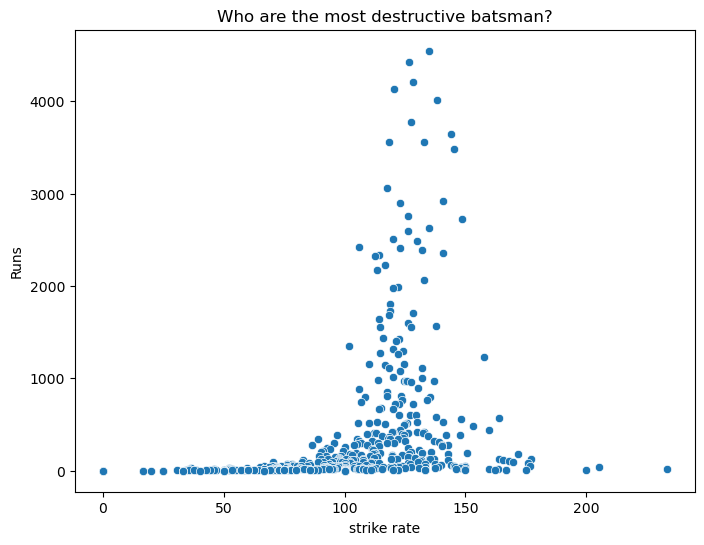

In [95]:
# Q5. Who are the most destructive batsmen?abs

plt.figure(figsize=(8,6))
sea.scatterplot(data=df, x='strike_rate', y='batsman_runs', legend=True)
plt.title("Who are the most destructive batsman?")
plt.xlabel("strike rate")
plt.ylabel("Runs")
plt.show()

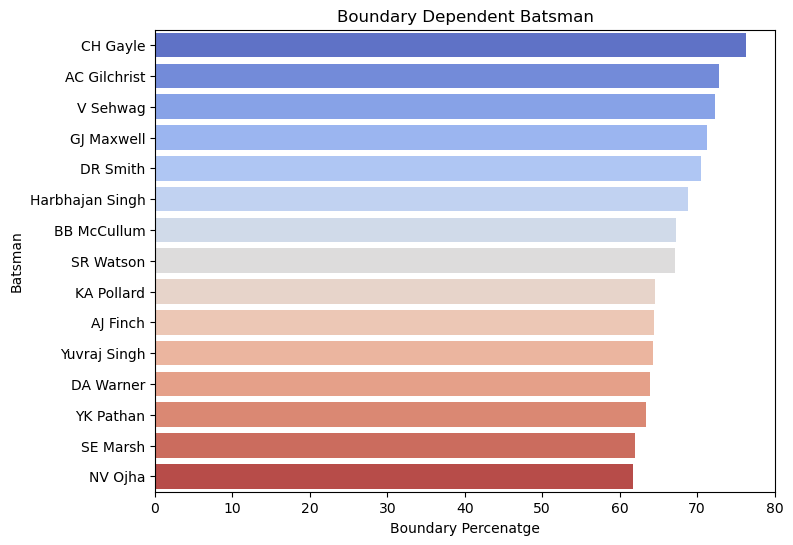

In [96]:
# Q6. Boundary dependent batsmans



df_plot = df[df['matches_played'] >= 50].sort_values(by='boundary_percentage', ascending=False)
plt.figure(figsize=(8,6))
sea.barplot(data=df_plot.head(15), x='boundary_percentage', y='batsman',hue='batsman', palette='coolwarm',legend=False)
plt.title("Boundary Dependent Batsman")
plt.xlabel("Boundary Percenatge")
plt.ylabel("Batsman")
plt.show()


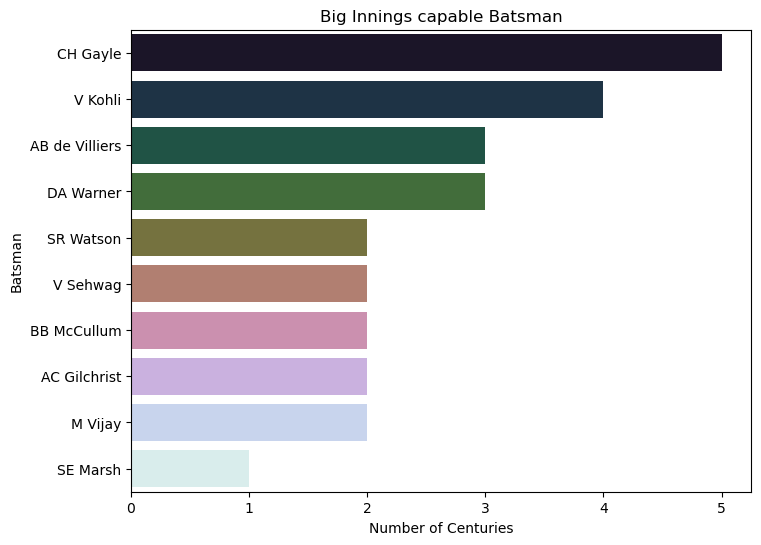

In [97]:
# Q7. Who converts starts into big innings.abs

df_plot = df[df['matches_played'] >= 50].sort_values(by='no_of_100s', ascending=False)

plt.figure(figsize=(8,6))
sea.barplot(data=df_plot.head(10), x='no_of_100s', y='batsman',hue='batsman',palette='cubehelix')
plt.title("Big Innings capable Batsman")
plt.xlabel("Number of Centuries")
plt.ylabel("Batsman")
plt.show()

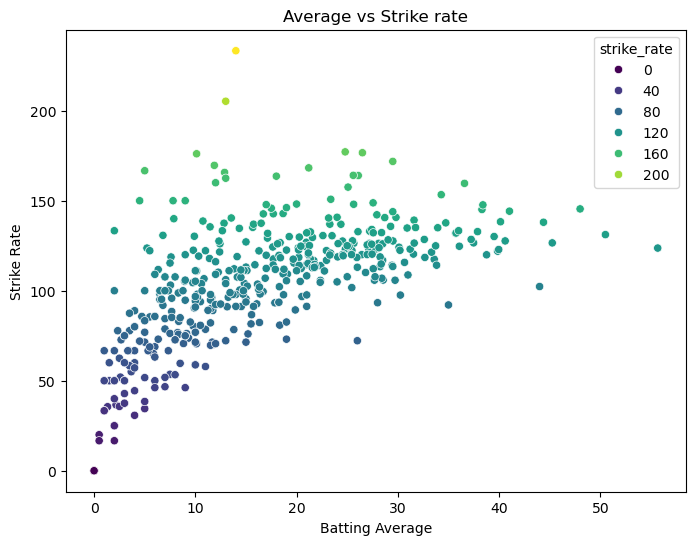

In [98]:
# Q8. Average vs Strike Rate

plt.figure(figsize=(8,6))
sea.scatterplot(data=df, x='batting_average', y='strike_rate', hue='strike_rate', palette='viridis')
plt.title("Average vs Strike rate")
plt.xlabel("Batting Average")
plt.ylabel("Strike Rate")
plt.show()

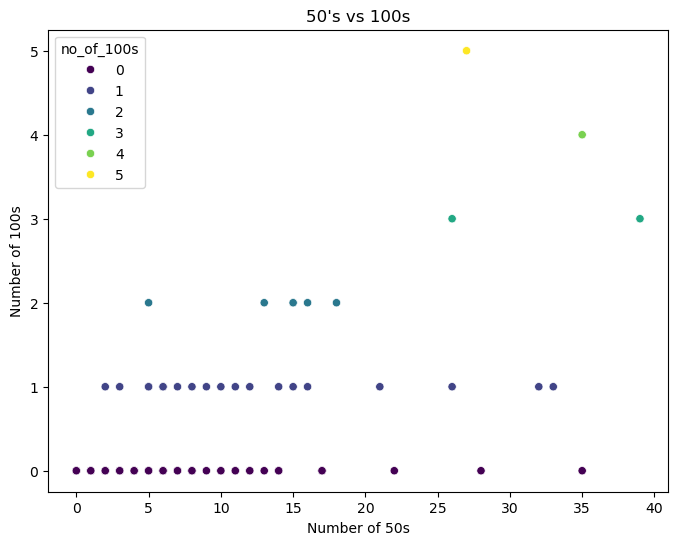

In [99]:
# Q9. 50s vs 100sabs
plt.figure(figsize=(8,6))
sea.scatterplot(data=df, x='no_of_50s', y='no_of_100s', palette= 'viridis', hue='no_of_100s')
plt.title("50's vs 100s")
plt.xlabel("Number of 50s")
plt.ylabel("Number of 100s")
plt.show()

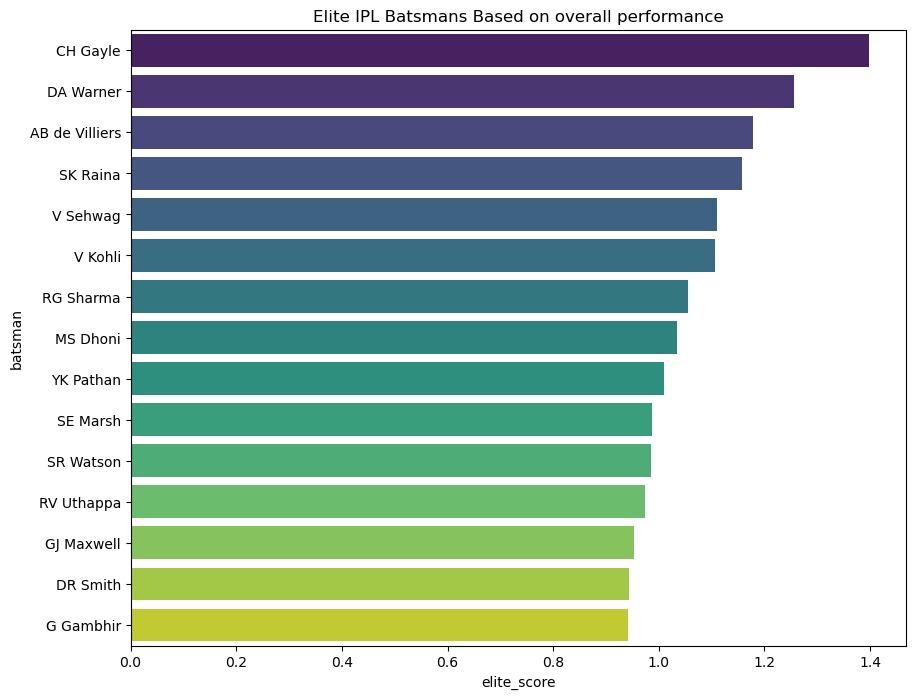

In [100]:
# Q10. Elite Batsman Scores.

elite_batsman = df.copy()

elite_batsman = elite_batsman[elite_batsman['matches_played']>= 50]

#normalising batsman_runs
# batting_average
# strike_rate
# boundary_percentage

elite_batsman['batsman_runs_score'] = (elite_batsman['batsman_runs'] - elite_batsman['batsman_runs'].min()
                                      ) / (elite_batsman['batsman_runs'].max() - elite_batsman['batsman_runs'].min())

elite_batsman['batsman_average_score'] = (elite_batsman['batting_average'] - elite_batsman['batting_average'].min()
                                      ) / (elite_batsman['batting_average'].max() - elite_batsman['batting_average'].min())

elite_batsman['strike_rate_score'] = (elite_batsman['strike_rate'] - elite_batsman['strike_rate'].min()
                                      ) / (elite_batsman['strike_rate'].max() - elite_batsman['strike_rate'].min())

elite_batsman['boundary_percentage_score'] = (elite_batsman['boundary_percentage'] - elite_batsman['boundary_percentage'].min()
                                      ) / (elite_batsman['boundary_percentage'].max() - elite_batsman['boundary_percentage'].min())

elite_batsman['elite_score'] = (elite_batsman['batsman_runs_score'] * 0.5 +
                                elite_batsman['batsman_average_score']*0.4 +
                                elite_batsman['strike_rate_score']*0.4 +
                                elite_batsman['boundary_percentage_score']*0.3)

elite_batsman = elite_batsman.sort_values(by='elite_score', ascending=False)

elite_batsman[['batsman','elite_score']].head(15)

plt.figure(figsize=(10,8))
sea.barplot(data=elite_batsman.head(15), x='elite_score', y='batsman', hue='batsman', palette='viridis',)
plt.title("Elite IPL Batsmans Based on overall performance")
plt.show()

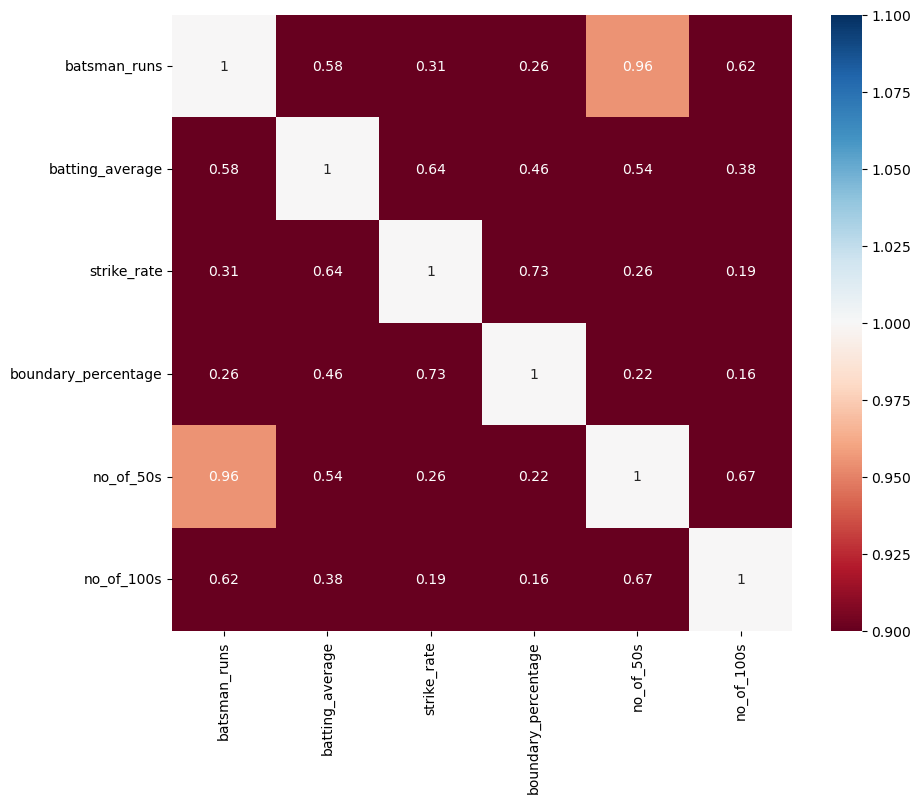

In [101]:
# Q11. Correlation heatmaps

selected_columns = df[['batsman_runs',
                        'batting_average',
                        'strike_rate',
                        'boundary_percentage',
                        'no_of_50s',
                        'no_of_100s']]

selected_corr = selected_columns.corr()

plt.figure(figsize=(10,8))
sea.heatmap(data=selected_corr,annot=True,cmap='RdBu',vmin=1,vmax=1)
plt.show()

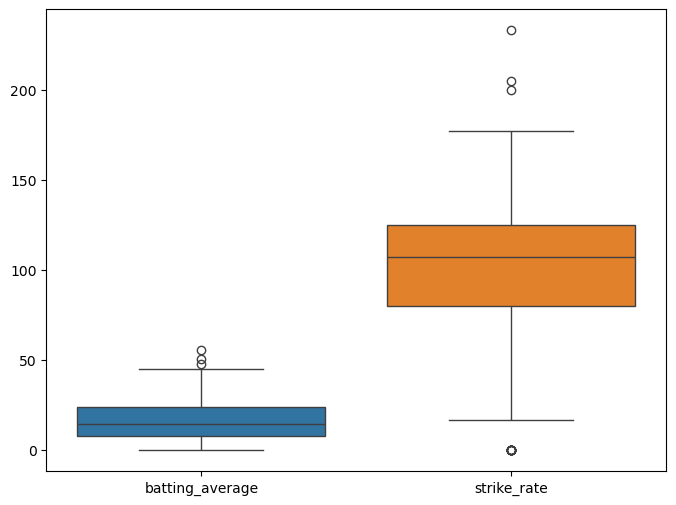

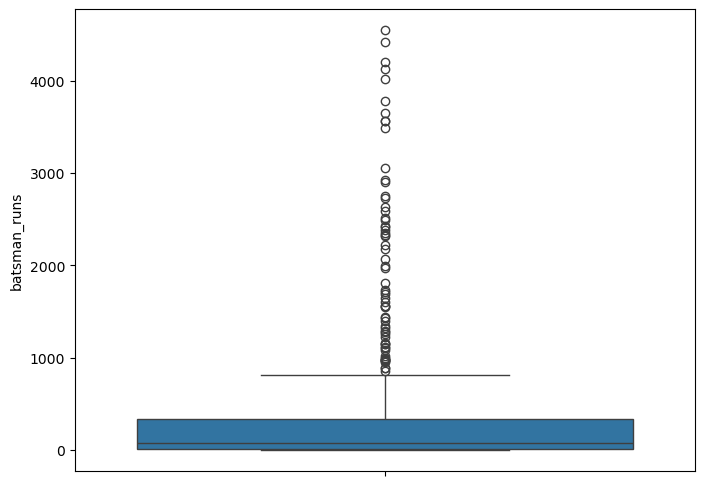

In [102]:
df_boxplot = df[['batting_average', 'strike_rate']]
df_plot = df['batsman_runs']
plt.figure(figsize=(8,6))
sea.boxplot(data=df_boxplot)
plt.show()

plt.figure(figsize=(8,6))
sea.boxplot(data=df_plot)
plt.show()

In [103]:
# key Insights

In [104]:
# limitations

In [105]:
df.columns


Index(['Unnamed: 0', 'batsman', 'batsman_runs', 'no.of_balls',
       'dismissals_count', 'matches_played', 'strike_rate', 'batting_average',
       'batting_team', 'no_of_fours', 'no_of_sixes', 'boundary_percentage',
       'no_of_100s', 'no_of_50s'],
      dtype='object')

## Matches Dataset Analysis:

In [106]:
dataset = pd.read_csv("matches.csv")

In [107]:
display(dataset.head(4))

display(dataset.info())

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 756 entries, 0 to 755
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               756 non-null    int64 
 1   season           756 non-null    int64 
 2   city             749 non-null    object
 3   date             756 non-null    object
 4   team1            756 non-null    object
 5   team2            756 non-null    object
 6   toss_winner      756 non-null    object
 7   toss_decision    756 non-null    object
 8   result           756 non-null    object
 9   dl_applied       756 non-null    int64 
 10  winner           752 non-null    object
 11  win_by_runs      756 non-null    int64 
 12  win_by_wickets   756 non-null    int64 
 13  player_of_match  752 non-null    object
 14  venue            756 non-null    object
 15  umpire1          754 non-null    object
 16  umpire2          754 non-null    object
 17  umpire3          119 non-null    ob

None

In [108]:
display(df.describe())

,Unnamed: 0,batsman_runs,no.of_balls,dismissals_count,matches_played,strike_rate,batting_average,no_of_fours,no_of_sixes,boundary_percentage,no_of_100s,no_of_50s
count,461.000000,461.000000,461.00000,461.000000,461.000000,461.000000,461.000000,461.000000,461.000000,461.000000,461.000000,461.000000
mean,230.000000,398.978308,326.37744,16.132321,20.639913,101.712258,inf,36.947939,14.149675,45.507274,0.101952,2.075922
std,133.223496,785.443358,617.31306,25.190532,29.984642,36.449593,NaN,75.904986,31.041440,24.784574,0.462056,5.502636
min,0.000000,0.000000,1.00000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,115.000000,15.000000,18.00000,2.000000,3.000000,80.000000,8.000000,1.000000,0.000000,36.363636,0.000000,0.000000
50%,230.000000,73.000000,71.00000,6.000000,8.000000,107.407407,15.666667,6.000000,2.000000,52.631579,0.000000,0.000000
75%,345.000000,342.000000,285.00000,19.000000,23.000000,125.000000,25.636364,30.000000,13.000000,61.650993,0.000000,1.000000
max,460.000000,4548.000000,3494.00000,134.000000,157.000000,233.333333,inf,484.000000,266.000000,100.000000,5.000000,39.000000


In [109]:
display(dataset.isna().sum())

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               4
win_by_runs          0
win_by_wickets       0
player_of_match      4
venue                0
umpire1              2
umpire2              2
umpire3            637
dtype: int64

In [110]:
match_dataset = dataset.copy()

match_dataset.columns

Index(['id', 'season', 'city', 'date', 'team1', 'team2', 'toss_winner',
       'toss_decision', 'result', 'dl_applied', 'winner', 'win_by_runs',
       'win_by_wickets', 'player_of_match', 'venue', 'umpire1', 'umpire2',
       'umpire3'],
      dtype='object')

In [120]:
umpire1_mode = match_dataset['umpire1'].mode()[0]
umpire2_mode = match_dataset['umpire2'].mode()[0]


match_dataset['umpire1'] = match_dataset['umpire1'].fillna(umpire1_mode) # reassgn
match_dataset['umpire2'] = match_dataset['umpire2'].fillna(umpire2_mode)
match_dataset['umpire3'] = match_dataset['umpire3'].fillna("umpire3")



## I went over the injternet and found that 4 matches were cancelled due to rain so that is the main reason for NaN in winner and POTM.abs

match_dataset['player_of_match'] = match_dataset['player_of_match'].fillna("N/A")
match_dataset['winner'] = match_dataset['winner'].fillna("N/A")

display(match_dataset.isna().sum())

# Filling missing city values
display(match_dataset[match_dataset['city'].isna()])

match_dataset['city'] = np.where(match_dataset['venue'] == 'Dubai International Cricket Stadium',
                                 match_dataset['city'].fillna('Dubai'), match_dataset['city'])
display(match_dataset[match_dataset['city'].isna()])

display(match_dataset.isna().sum())

id                 0
season             0
city               0
date               0
team1              0
team2              0
toss_winner        0
toss_decision      0
result             0
dl_applied         0
winner             0
win_by_runs        0
win_by_wickets     0
player_of_match    0
venue              0
umpire1            0
umpire2            0
umpire3            0
dtype: int64

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3


,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3


id                 0
season             0
city               0
date               0
team1              0
team2              0
toss_winner        0
toss_decision      0
result             0
dl_applied         0
winner             0
win_by_runs        0
win_by_wickets     0
player_of_match    0
venue              0
umpire1            0
umpire2            0
umpire3            0
dtype: int64

In [147]:
team_name_mapp = {
                  'Rising Pune Supergiants' : 'Rising Pune Supergiant',
                  'Rising Pune Supergiats' : 'Rising Pune Supergiant',
                  'Delhi Daredevils':'Delhi Capitals',
                  'Deccan Chargers':'Sunrisers Hyderabad'
}

city_mapp= {
    "Bengaluru":"Bangalore"
}

def standardize_city_names(df, columns):
    for col in columns:
        df[col] = df[col].replace(city_mapp)
    return df

def standardize_team_names(df,columns):
  for col in columns:
    df[col] = df[col].replace(team_name_mapp)
  return df

team_columns =['team1','team2','toss_winner','winner']
match_dataset= standardize_team_names(match_dataset,team_columns)

city_column = ['city']
match_dataset = standardize_city_names(match_dataset, city_column)

In [149]:
# match_dataset['city'].value_counts()

In [123]:
match_dataset['team1'].value_counts()

team1
Sunrisers Hyderabad            106
Mumbai Indians                 101
Kings XI Punjab                 91
Chennai Super Kings             89
Royal Challengers Bangalore     85
Kolkata Knight Riders           83
Delhi Capitals                  78
Rajasthan Royals                67
Pune Warriors                   20
Rising Pune Supergiant          15
Gujarat Lions                   14
Kochi Tuskers Kerala             7
Name: count, dtype: int64

In [124]:
# matches_dataset = match_dataset.to_csv("cleaned_matches.csv")


## EDA ON MATCHES_DATASET

,winner,count
0,Mumbai Indians,109
1,Chennai Super Kings,100
2,Kolkata Knight Riders,92
3,Sunrisers Hyderabad,87
4,Royal Challengers Bangalore,84
5,Kings XI Punjab,82
6,Delhi Capitals,77
7,Rajasthan Royals,75
8,Rising Pune Supergiant,15
9,Gujarat Lions,13


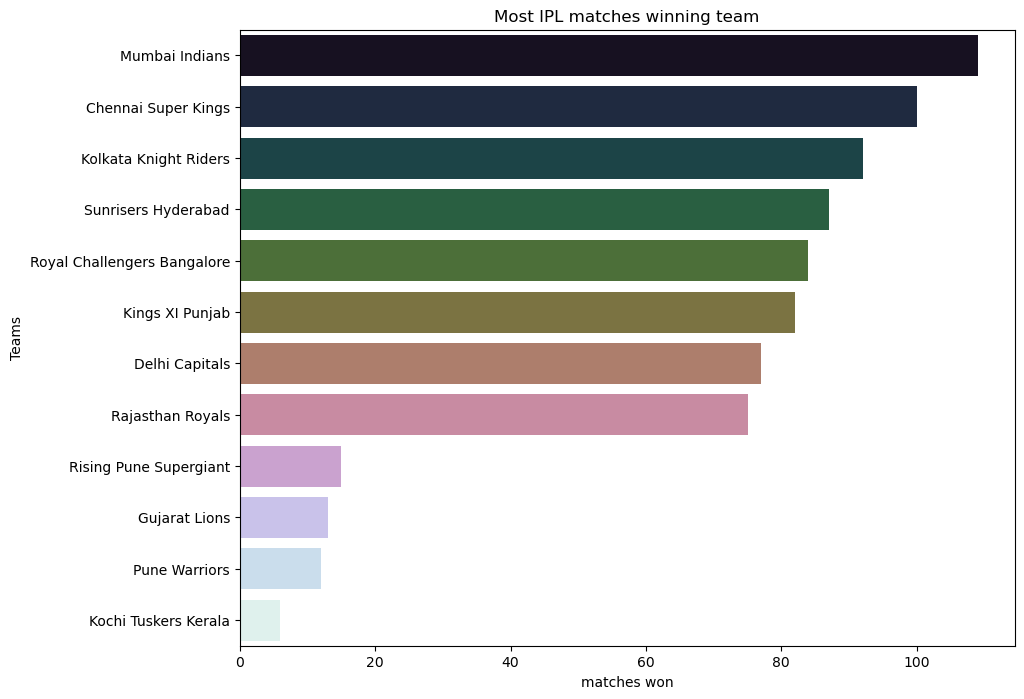

In [139]:
# Q1. Which teams have won most matchesin IPL

df_plot = match_dataset['winner'].value_counts().reset_index()

df_plot = df_plot[df_plot['winner'] != 'N/A']

display(df_plot)

plt.figure(figsize=(10,8))
sea.barplot(data=df_plot, x='count', y='winner', hue='winner', palette='cubehelix', legend=False)
plt.title("Most IPL matches winning team")
plt.xlabel("matches won")
plt.ylabel("Teams")
plt.show()

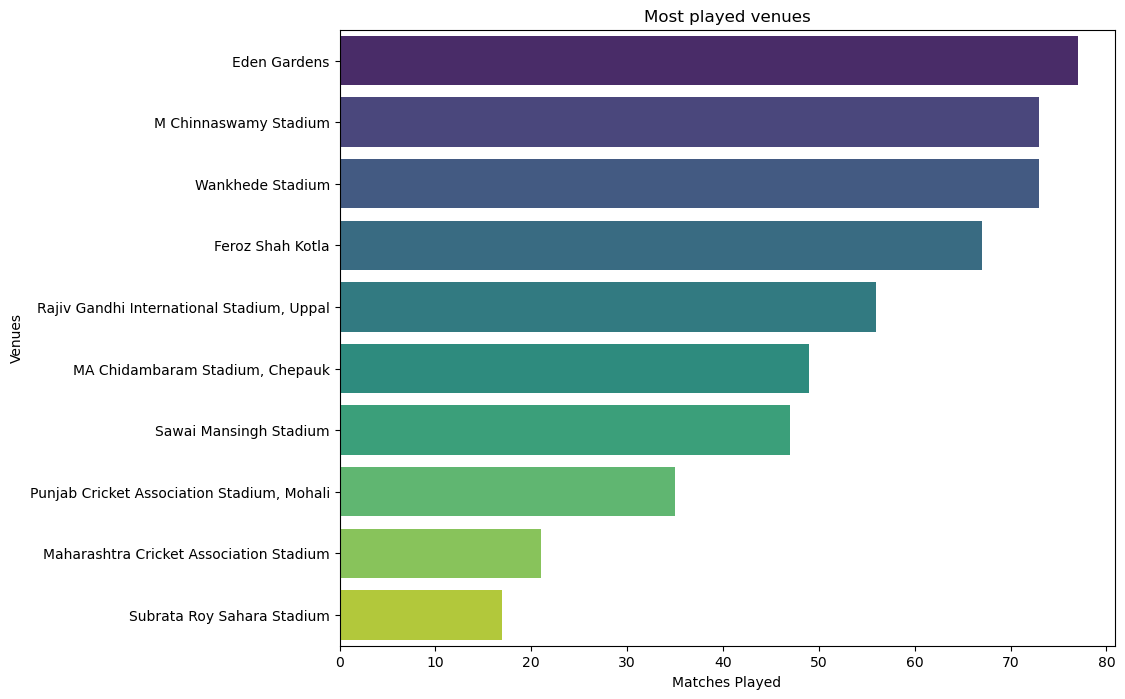

In [142]:
# Q2. Which venue has hosted the most matches in IPl.abs

df_plot = match_dataset['venue'].value_counts().reset_index()

plt.figure(figsize=(10,8))
sea.barplot(data=df_plot.head(10), x='count', y='venue',hue='venue', palette='viridis', legend=False)
plt.title("Most played venues")
plt.xlabel("Matches Played")
plt.ylabel("Venues")
plt.show()

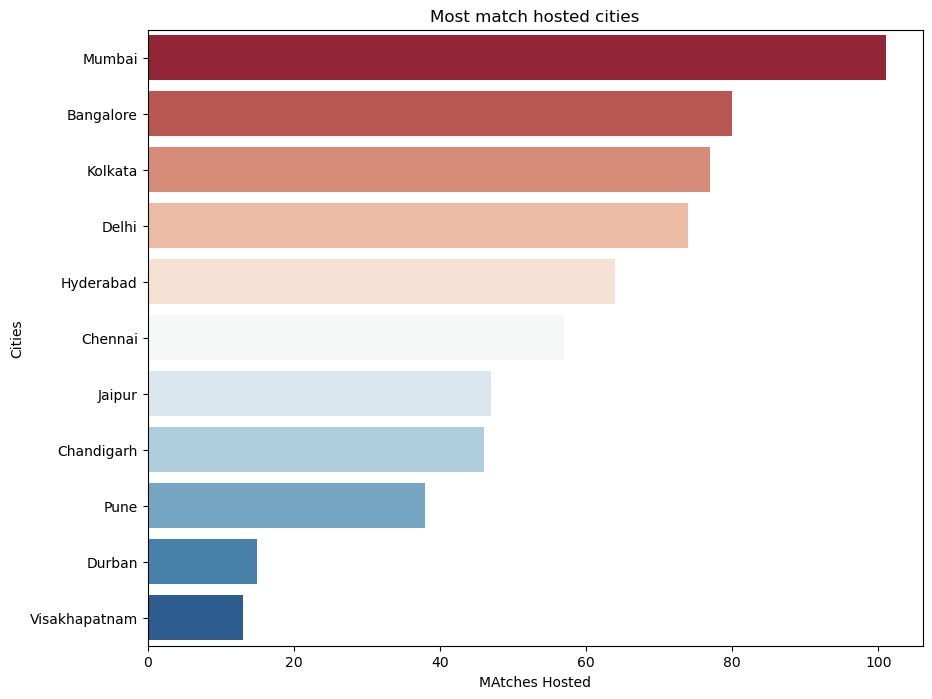

In [150]:
# Q3. Which cities has hosted most matches

df_plot = match_dataset['city'].value_counts().reset_index()

plt.figure(figsize=(10,8))
sea.barplot(data=df_plot.head(11), x='count', y='city', hue='city', palette='RdBu', legend=False)
plt.title("Most match hosted cities")
plt.xlabel("MAtches Hosted")
plt.ylabel("Cities")
plt.show()

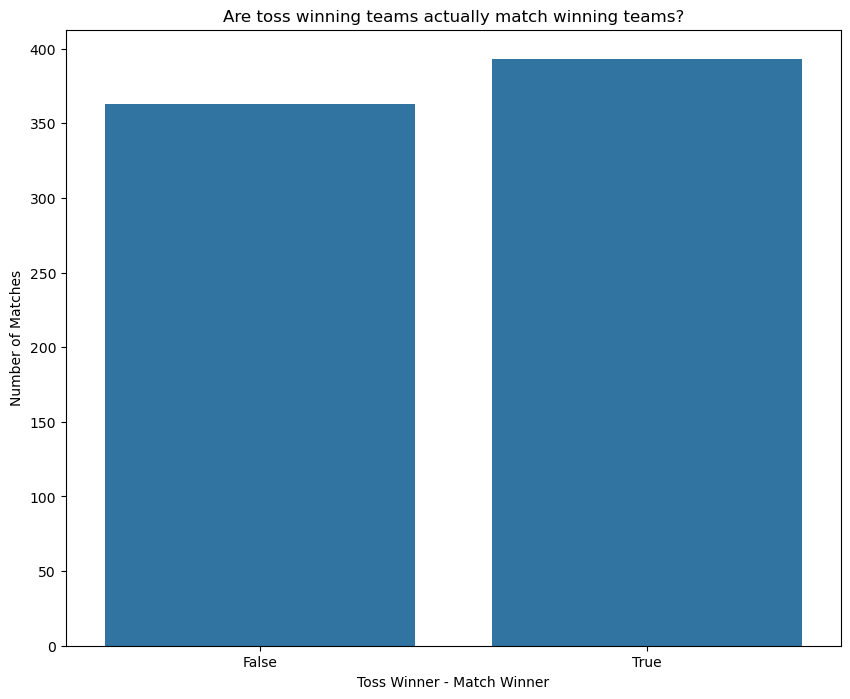

In [153]:
# Q4. Does toss winning actually help?

match_dataset['toss_match_win'] = (
    match_dataset['toss_winner'] == match_dataset['winner']
)

plt.figure(figsize=(10,8))
sea.countplot(data=match_dataset, x='toss_match_win', legend=True)
plt.title("Are toss winning teams actually match winning teams?")
plt.xlabel("Toss Winner - Match Winner")
plt.ylabel("Number of Matches")
plt.show()

In [159]:
# better analysis

match_dataset['toss_match_win'].value_counts(normalize=True)*100


toss_match_win
True     51.984127
False    48.015873
Name: proportion, dtype: float64

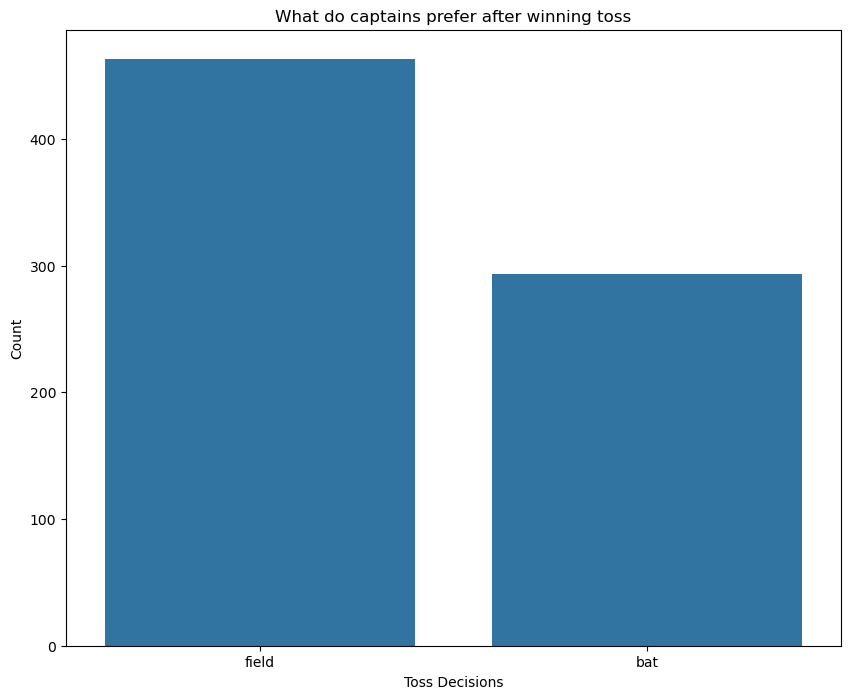

In [160]:
# Q5. What do captains prefer after toss :

plt.figure(figsize=(10,8))
sea.countplot(data=match_dataset, x='toss_decision')
plt.title("What do captains prefer after winning toss")
plt.xlabel("Toss Decisions")
plt.ylabel("Count")
plt.show()


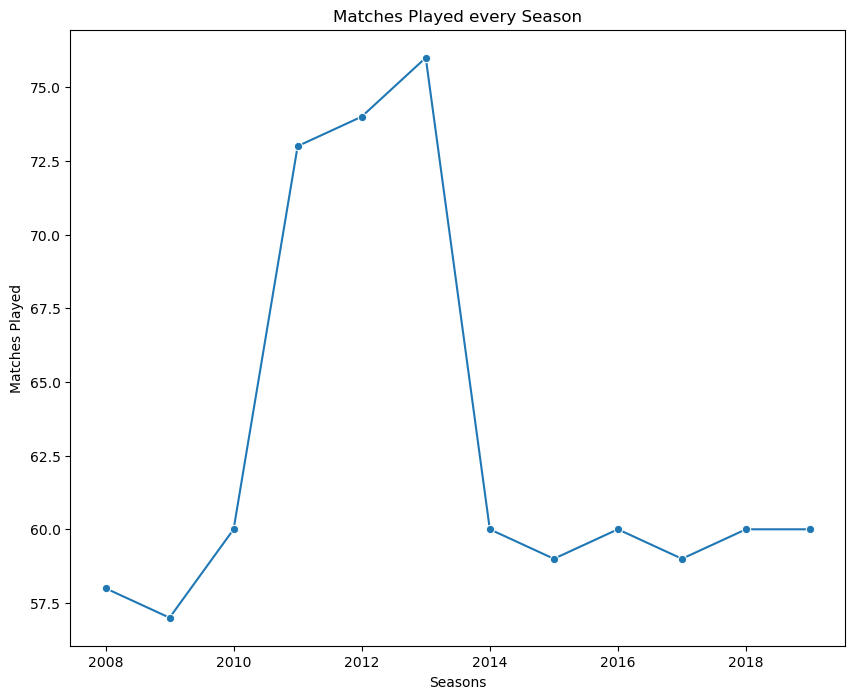

In [174]:
# Q6. How many matches were played every season

matches_per_season = match_dataset['season'].value_counts().reset_index().sort_index()



# display(matches_per_season.sort_values(by='season'))


plt.figure(figsize=(10,8))
sea.lineplot(data=matches_per_season.sort_values(by='season'), x='season',y='count',marker='o')
plt.title("Matches Played every Season")
plt.xlabel("Seasons")
plt.ylabel("Matches Played")
plt.show()

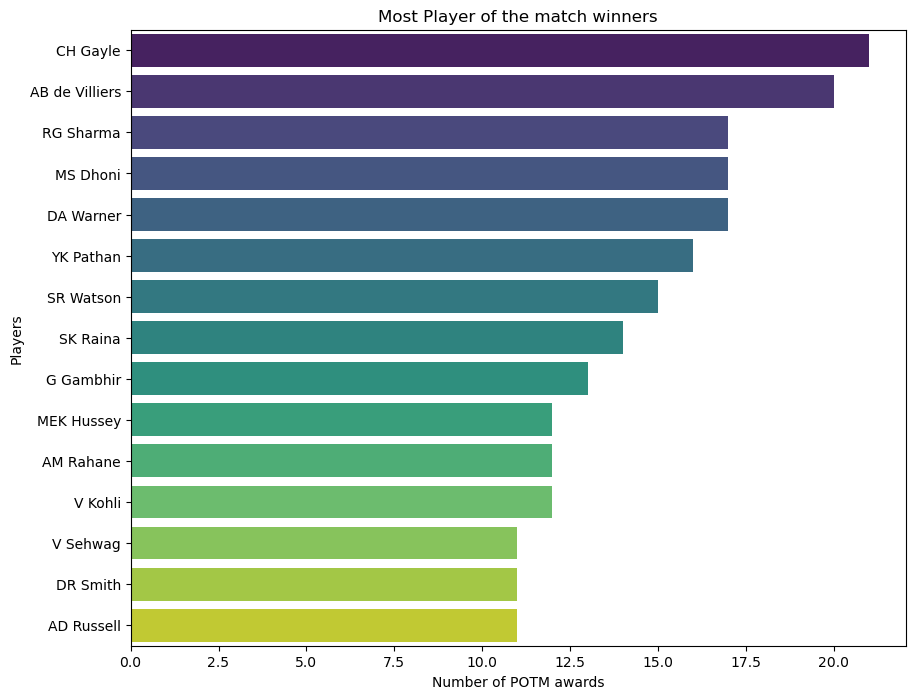

In [175]:
# Q Who won the most POTM award

df_plot = match_dataset['player_of_match'].value_counts().reset_index()

plt.figure(figsize=(10,8))
sea.barplot(data=df_plot.head(15), x='count', y='player_of_match', hue='player_of_match', palette='viridis')
plt.title("Most Player of the match winners")
plt.xlabel("Number of POTM awards")
plt.ylabel("Players")
plt.show()

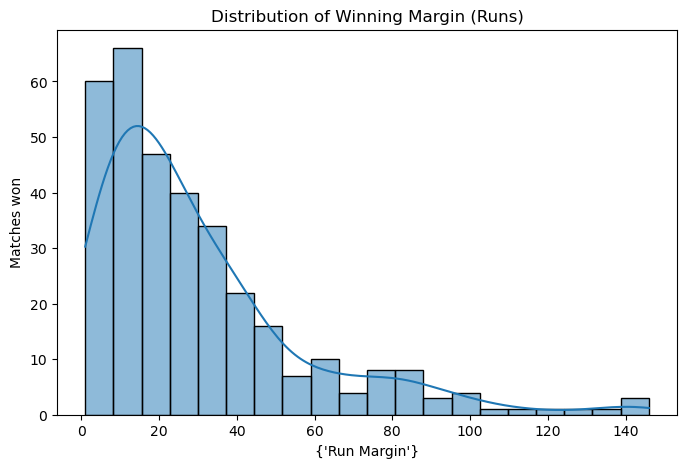

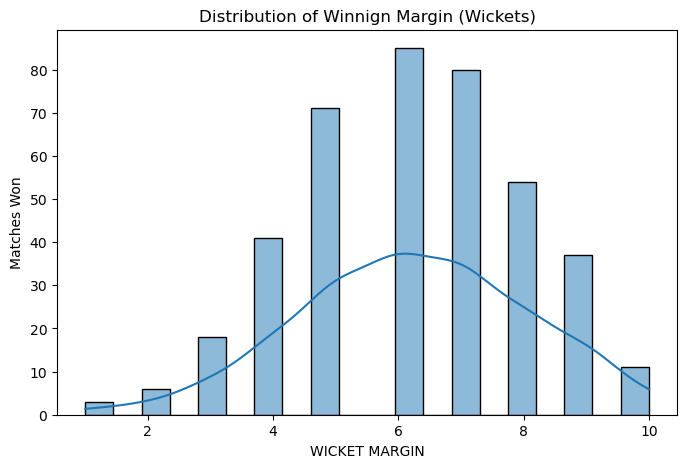

In [183]:
# Q8. How are matches usual
run_margin = match_dataset[match_dataset['win_by_runs'] > 0]

plt.figure(figsize=(8,5))

sea.histplot(
    data=run_margin,
    x='win_by_runs',
    bins=20,
    kde=True
)
plt.title("Distribution of Winning Margin (Runs)")
plt.xlabel({"Run Margin"})
plt.ylabel("Matches won")
plt.show()



wicket_margin = match_dataset[match_dataset['win_by_wickets'] > 0]
plt.figure(figsize=(8,5))
sea.histplot(
    data=wicket_margin,
    x= 'win_by_wickets',
    bins=20,
    kde=True
)
plt.title("Distribution of Winnign Margin (Wickets)")
plt.xlabel("WICKET MARGIN")
plt.ylabel("Matches Won")
plt.show()

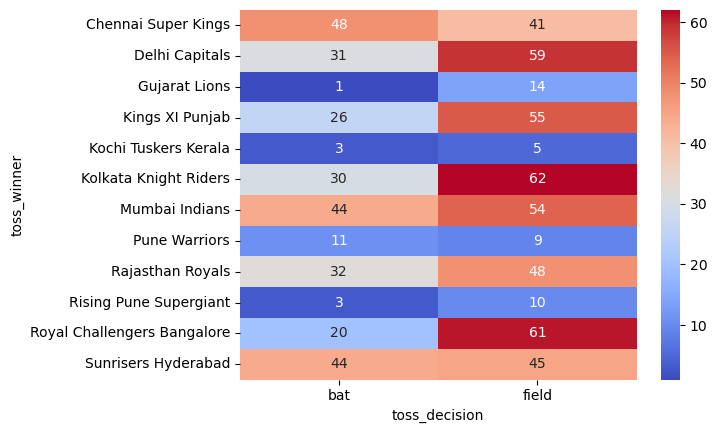

In [185]:
# Q9. Which team prefer batting first after winning toss.

data_heatmap = pd.crosstab(
    match_dataset['toss_winner'],
    match_dataset['toss_decision']
)

sea.heatmap(data_heatmap, cmap='coolwarm', annot=True, fmt='g')
plt.show()

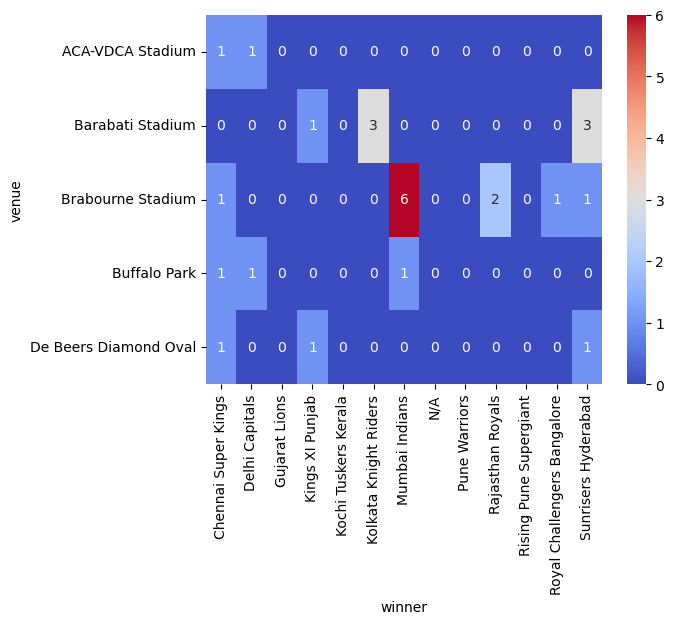

In [187]:
# Q10. which team dominate at venues

heatmap_plot = pd.crosstab(
    match_dataset['venue'],
    match_dataset['winner']
)


sea.heatmap(heatmap_plot.head(), cmap='coolwarm', annot=True,fmt='g')
plt.show()

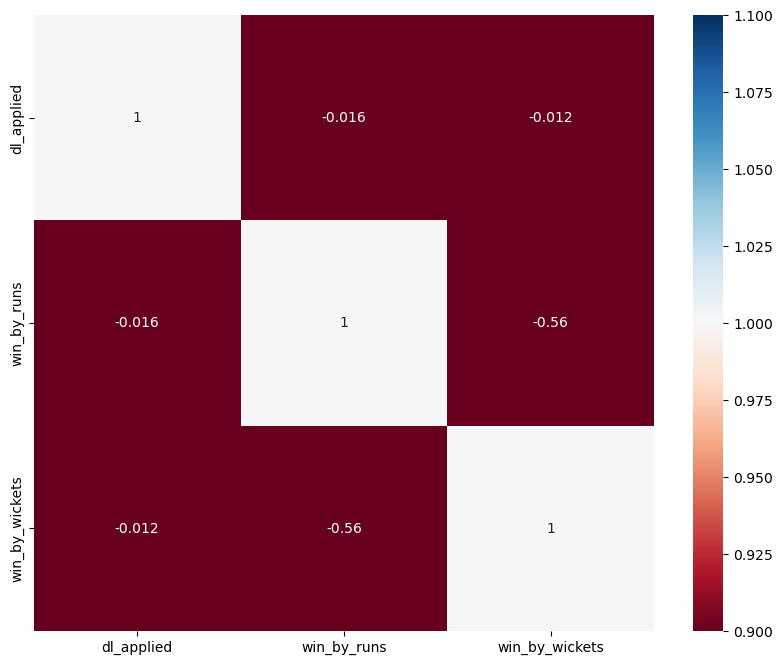

In [188]:

selected_columns = match_dataset[['dl_applied', "win_by_runs", "win_by_wickets"]]

selected_corr = selected_columns.corr()

plt.figure(figsize=(10,8))
sea.heatmap(data=selected_corr,annot=True,cmap='RdBu',vmin=1,vmax=1)
plt.show()